这是用来查看论文数据的文档，主要是进行数据截取以及数据清洗，前者是将大量数据简化成便于分析的小规模数据，后者是将部分不满足论文要求的数据进行清洗。

思路：

1、数据导入，数据清洗

2、Q1:价格与评分系统的关系

3、



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import json
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

In [5]:
business = pd.read_json(
    "/Users/liyou/vs code/论文/论文数据/Yelp JSON/yelp_academic_dataset_business.json",
    lines=True,
    encoding="utf-8"
)

# 基本查看
business.head()


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [6]:
review = pd.read_json(
    "/Users/liyou/vs code/论文/论文数据/Yelp JSON/yelp_academic_dataset_review.json",
    lines=True,
    chunksize=50000,
    encoding="utf-8"
)

review = next(review)
review.head()


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [7]:
def get_price(attr):
    if isinstance(attr, dict):
        return attr.get("RestaurantsPriceRange2")
    return None

business["price_level"] = business["attributes"].apply(get_price)

business["price_level"] = pd.to_numeric(business["price_level"], errors="coerce")

print(business["price_level"].value_counts())

price_level
2.0    48581
1.0    28840
3.0     6667
4.0     1192
Name: count, dtype: int64


In [8]:
restaurants = business[business["categories"].str.contains("Restaurants", na=False)]

restaurants = restaurants[restaurants["categories"].str.contains("Chinese", na=False)]

restaurants = restaurants.dropna(subset=["price_level"])

print("餐饮商家数量:", restaurants.shape)




餐饮商家数量: (2774, 15)


In [10]:
restaurants.to_excel(r"/Users/liyou/vs code/论文/论文数据/全部中餐厅数据.xlsx", index=False)

需要保存的的变量😊

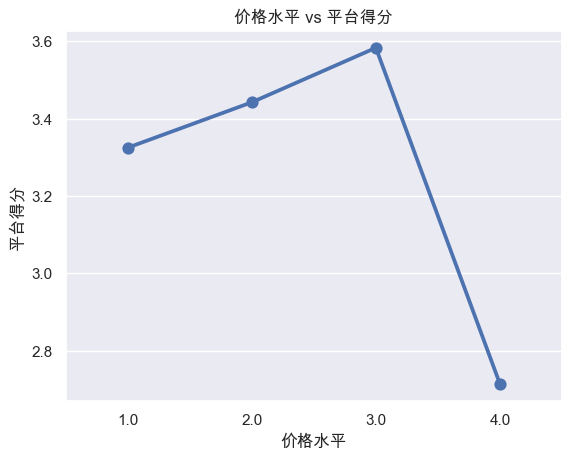

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------- Mac 正确中文字体设置 ----------
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号方块
# 关键：seaborn 也要指定字体
sns.set(font='Arial Unicode MS')
# -------------------------------------------

# 分组计算（你的变量名是 df，不是 restaurants！）
price_rating = restaurants.groupby('price_level')['stars'].mean().reset_index()

# 画图
sns.pointplot(x='price_level', y='stars', data=price_rating)

plt.xlabel("价格水平")
plt.ylabel("平台得分")
plt.title("价格水平 vs 平台得分")
plt.show()




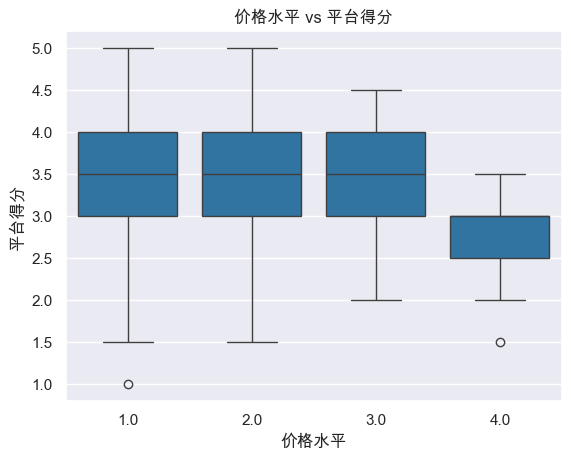

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 画箱线图（按价格分组）
plt.figure()
sns.boxplot(
    x='price_level',
    y='stars',
    data=restaurants,
    color='#1f77b4'   # 👈 和前面保持一致
)

plt.xlabel("价格水平")
plt.ylabel("平台得分")
plt.title("价格水平 vs 平台得分")

plt.show()

In [11]:
import statsmodels.api as sm
import pandas as pd

# 自变量 & 因变量
X_price = restaurants['price_level']
y = restaurants['stars']

# 加常数项
X_price = sm.add_constant(X_price)

# 回归
model_price = sm.OLS(y, X_price).fit()

# 提取结果
result_price = pd.DataFrame({
    "Coefficient": model_price.params,
    "Std_Error": model_price.bse,
    "t_value": model_price.tvalues,
    "p_value": model_price.pvalues
})

print("=== Price → Rating 回归结果 ===")
print(result_price)
print("R² (Price → Rating):", model_price.rsquared)
print("Adjusted R²:", model_price.rsquared_adj)

=== Price → Rating 回归结果 ===
             Coefficient  Std_Error    t_value   p_value
const           3.236900   0.036898  87.725761  0.000000
price_level     0.096324   0.023256   4.141900  0.000035
R² (Price → Rating): 0.006150726497921477
Adjusted R²: 0.0057921950139741


/var/folders/xr/7y1px47j55dfjhnt336_w7600000gn/T/ipykernel_63833/569088227.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_rating = restaurants.groupby('review_bin')['stars'].mean().reset_index()


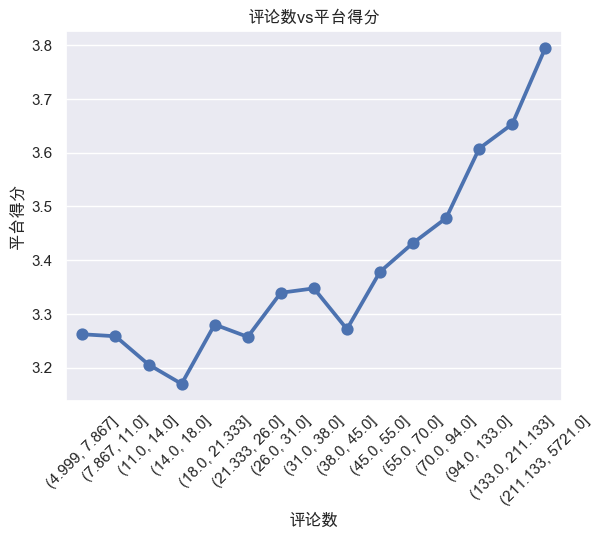

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 分成5组（你也可以改成4组）
restaurants['review_bin'] = pd.qcut(restaurants['review_count'], q=15)

# 计算每组平均评分
review_rating = restaurants.groupby('review_bin')['stars'].mean().reset_index()

# 画图
plt.figure()
sns.pointplot(x='review_bin', y='stars', data=review_rating)

plt.xticks(rotation=45)
plt.xlabel("评论数")
plt.ylabel("平台得分")
plt.title("评论数vs平台得分")

plt.show()

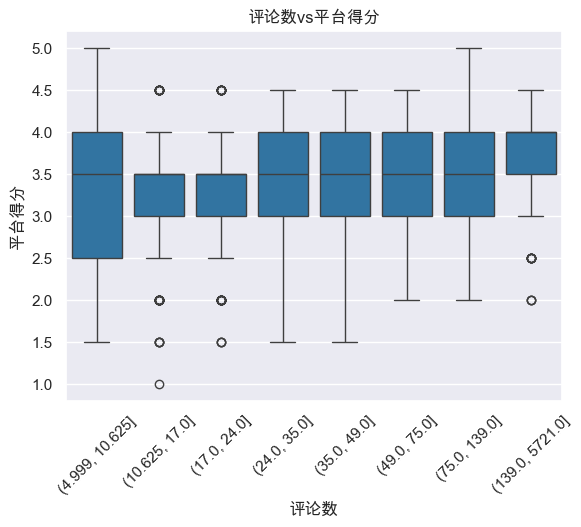

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 分箱
restaurants['review_bin'] = pd.qcut(restaurants['review_count'], q=8)

# 画图（全部强制为蓝色）
plt.figure()
sns.boxplot(
    x='review_bin',
    y='stars',
    data=restaurants,
    color='#1f77b4'   # 👈 统一指定蓝色
)

plt.xticks(rotation=45)
plt.xlabel("评论数")
plt.ylabel("平台得分")
plt.title("评论数vs平台得分")

plt.show()

In [14]:
# 自变量 & 因变量
X_review = restaurants['review_count']
y = restaurants['stars']

# 加常数项
X_review = sm.add_constant(X_review)

# 回归
model_review = sm.OLS(y, X_review).fit()

# 提取结果
result_review = pd.DataFrame({
    "Coefficient": model_review.params,
    "Std_Error": model_review.bse,
    "t_value": model_review.tvalues,
    "p_value": model_review.pvalues
})

print("=== Review Count → Rating 回归结果 ===")
print(result_review)
print("R² (Review Count → Rating):", model_review.rsquared)
print("Adjusted R²:", model_review.rsquared_adj)

=== Review Count → Rating 回归结果 ===
              Coefficient  Std_Error     t_value       p_value
const            3.332180   0.013187  252.685817  0.000000e+00
review_count     0.000662   0.000071    9.367915  1.483449e-20
R² (Review Count → Rating): 0.03068715649694187
Adjusted R²: 0.030337476538968233


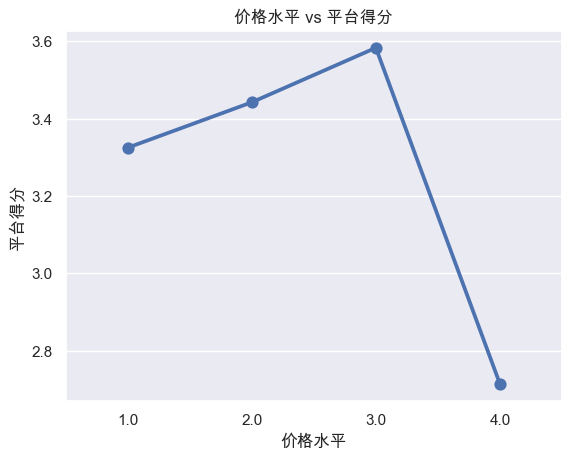

/Users/liyou/vs code/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


CART 回归树结果（可直接写论文）
价格水平 1.0 → 预测评分 3.325
价格水平 2.0 → 预测评分 3.444
价格水平 3.0 → 预测评分 3.444
价格水平 4.0 → 预测评分 2.714

模型 R² = 0.0111

结论：价格与评分呈倒U型非线性关系


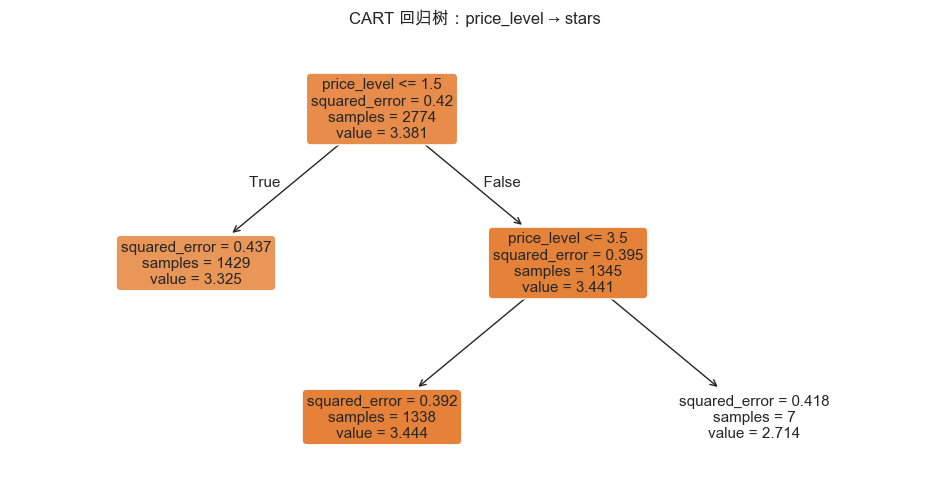

In [15]:

plt.rcParams['font.sans-serif'] = ['PingFang SC']
plt.rcParams['axes.unicode_minus'] = False


price_rating = restaurants.groupby('price_level')['stars'].mean().reset_index()

sns.pointplot(x='price_level', y='stars', data=price_rating)
plt.xlabel("价格水平")
plt.ylabel("平台得分")
plt.title("价格水平 vs 平台得分")
plt.show()


X = restaurants[['price_level']]  
y = restaurants['stars']          

# 训练CART回归树
cart_model = DecisionTreeRegressor(max_depth=2, random_state=42)
cart_model.fit(X, y)

# 输出每个价格水平的预测评分
price_levels = sorted(restaurants['price_level'].unique())
predicted_stars = cart_model.predict(np.array(price_levels).reshape(-1, 1))

print("=" * 50)
print("CART 回归树结果（可直接写论文）")
print("=" * 50)
for p, s in zip(price_levels, predicted_stars):
    print(f"价格水平 {p} → 预测评分 {s:.3f}")

print(f"\n模型 R² = {r2_score(y, cart_model.predict(X)):.4f}")
print("\n结论：价格与评分呈倒U型非线性关系")

# 画出CART树
plt.figure(figsize=(12, 6))
plot_tree(cart_model, feature_names=['price_level'], filled=True, rounded=True, fontsize=11)
plt.title("CART 回归树：price_level → stars")
plt.savefig("CART_tree.png", dpi=300, bbox_inches='tight')
plt.show()

/Users/liyou/vs code/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


随机森林回归结果（可直接写论文）
价格水平 1.0 → 预测评分 3.324
价格水平 2.0 → 预测评分 3.445
价格水平 3.0 → 预测评分 3.472
价格水平 4.0 → 预测评分 3.058

模型 R² = 0.0105
MSE = 0.4151


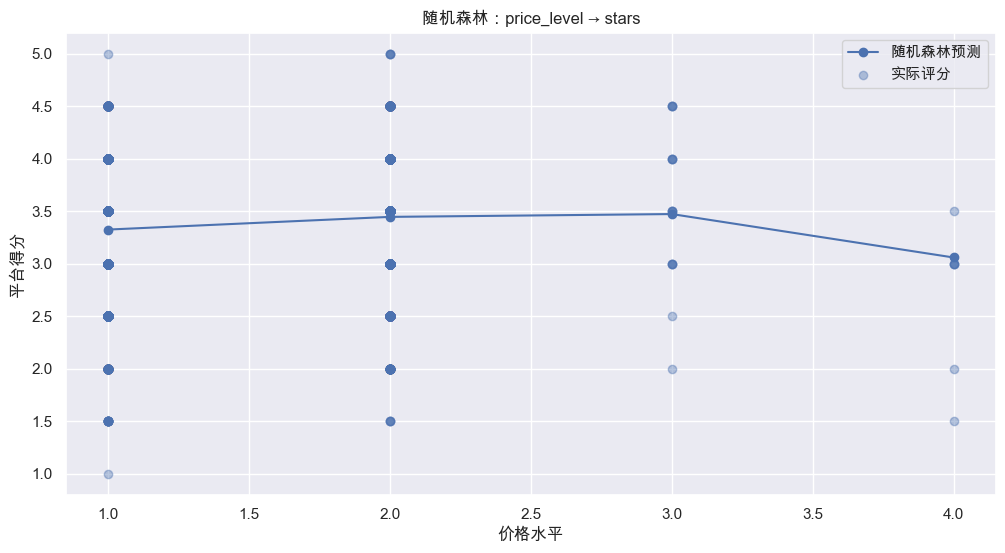

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 1. 准备数据
X = restaurants[['price_level']]
y = restaurants['stars']

# 2. 训练模型
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

# 3. 预测每个价格水平的评分
price_levels = sorted(restaurants['price_level'].unique())
predicted_stars = rf_model.predict(np.array(price_levels).reshape(-1, 1))

# 4. 输出结果
print("=" * 50)
print("随机森林回归结果（可直接写论文）")
print("=" * 50)
for p, s in zip(price_levels, predicted_stars):
    print(f"价格水平 {p} → 预测评分 {s:.3f}")

print(f"\n模型 R² = {r2_score(y, rf_model.predict(X)):.4f}")
print(f"MSE = {mean_squared_error(y, rf_model.predict(X)):.4f}")

# 5. 可视化
plt.figure(figsize=(12, 6))
plt.plot(price_levels, predicted_stars, marker='o', linestyle='-', label='随机森林预测')
plt.scatter(X['price_level'], y, alpha=0.4, label='实际评分')
plt.xlabel("价格水平")
plt.ylabel("平台得分")
plt.title("随机森林：price_level → stars")
plt.legend()
plt.show()

XGBoost 回归结果（可直接写论文）
价格水平 1.0 → 预测评分 3.326
价格水平 2.0 → 预测评分 3.438
价格水平 3.0 → 预测评分 3.556
价格水平 4.0 → 预测评分 2.727

模型 R² = 0.0114
MSE = 0.4147


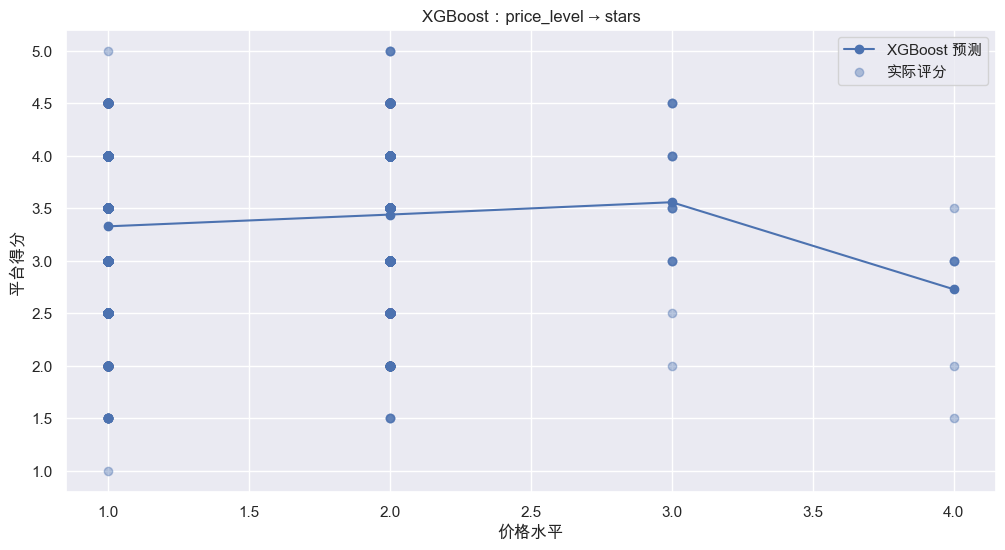

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. 准备数据
X = restaurants[['price_level']]
y = restaurants['stars']

# 2. 训练模型
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X, y)

# 3. 预测每个价格水平的评分
price_levels = sorted(restaurants['price_level'].unique())
predicted_stars = xgb_model.predict(np.array(price_levels).reshape(-1, 1))

# 4. 输出结果
print("=" * 50)
print("XGBoost 回归结果（可直接写论文）")
print("=" * 50)
for p, s in zip(price_levels, predicted_stars):
    print(f"价格水平 {p} → 预测评分 {s:.3f}")

print(f"\n模型 R² = {r2_score(y, xgb_model.predict(X)):.4f}")
print(f"MSE = {mean_squared_error(y, xgb_model.predict(X)):.4f}")

# 5. 可视化
plt.figure(figsize=(12, 6))
plt.plot(price_levels, predicted_stars, marker='o', linestyle='-', label='XGBoost 预测')
plt.scatter(X['price_level'], y, alpha=0.4, label='实际评分')
plt.xlabel("价格水平")
plt.ylabel("平台得分")
plt.title("XGBoost：price_level → stars")
plt.legend()
plt.show()